# KNN Classification — POC Features

Pipeline:
1. Load `poc_abs_flatten.xlsx` (per-frame)
2. Pisahkan external test set (per-subject)
3. Train SVM via `build_knn()` — Pipeline(Scaler → SVM balanced)
4. Split 60/40, 70/30, 80/20, 90/10
5. Metrik: UF1 (macro F1), UAR (macro recall), accuracy
6. External test


In [1]:
import sys, os
from pathlib import Path

ROOT = Path(os.getcwd()).resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent.parent
elif ROOT.name == "comparasion":
    ROOT = ROOT.parent
elif ROOT.name in {"lstm", "svm", "knn"}:
    ROOT = ROOT.parent.parent.parent
os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print(f"Project root: {ROOT}")

Project root: /home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    recall_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

from comparasion.core.models import build_knn, fit_model, predict

## 1. Load Data

In [3]:
FEATURE_PATH = Path("comparasion/output_casme2/features/poc_abs_flatten.xlsx")

df = pd.read_excel(FEATURE_PATH)
print(f"Shape: {df.shape}")

META_COLS = ["emotion", "subject", "clip", "frame", "label"]
feat_cols = [c for c in df.columns if c not in META_COLS]

print(f"Features: {len(feat_cols)}")
print(f"\nLabel dist:")
print(df["label"].value_counts())

Shape: (1151, 613)
Features: 608

Label dist:
label
Surprise     324
Happiness    305
Sadness      267
Disgust      255
Name: count, dtype: int64


## 2. External Test Set

Pisahkan 2 subject per emotion → external test. Sisanya = main (train+val).


In [4]:
SEED = 42

le = LabelEncoder()
df["label_enc"] = le.fit_transform(df["label"])
print(f"Classes: {list(le.classes_)}")

rng = np.random.RandomState(SEED)
external_subjects = set()

for emo in df["emotion"].unique():
    subjects_in_emo = df[df["emotion"] == emo]["subject"].unique()
    n_ext = min(1, len(subjects_in_emo))
    chosen = rng.choice(subjects_in_emo, size=n_ext, replace=False)
    external_subjects.update(chosen)

print(f"External subjects ({len(external_subjects)}): {sorted(external_subjects)}")

df_ext = df[df["subject"].isin(external_subjects)].copy()
df_main = df[~df["subject"].isin(external_subjects)].copy()

print(f"\nMain: {len(df_main)} rows")
print(f"External: {len(df_ext)} rows")
print(f"\nMain label dist:")
print(df_main["label"].value_counts())

Classes: ['Disgust', 'Happiness', 'Sadness', 'Surprise']
External subjects (4): [np.int64(6), np.int64(19), np.int64(20), np.int64(24)]

Main: 701 rows
External: 450 rows

Main label dist:
label
Happiness    250
Surprise     195
Disgust      150
Sadness      106
Name: count, dtype: int64


In [5]:
X_main = df_main[feat_cols].values
y_main = df_main["label_enc"].values

X_ext = df_ext[feat_cols].values
y_ext = df_ext["label_enc"].values

print(f"X_main: {X_main.shape}")
print(f"X_ext:  {X_ext.shape}")

X_main: (701, 608)
X_ext:  (450, 608)


## 3. Training — Tiap Split Terpisah


### Split 60/40

In [6]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_main, y_main, test_size=0.4, stratify=y_main, random_state=SEED
)

pipe = build_knn()
res = fit_model(pipe, X_tr, y_tr, model_name="SVM_4QMV_60/40")

y_tr_pred = predict(res.model, X_tr)
y_val_pred = predict(res.model, X_val)

train_acc = accuracy_score(y_tr, y_tr_pred)
val_acc = accuracy_score(y_val, y_val_pred)
train_f1 = f1_score(y_tr, y_tr_pred, average="macro")
val_f1 = f1_score(y_val, y_val_pred, average="macro")
train_uar = recall_score(y_tr, y_tr_pred, average="macro")
val_uar = recall_score(y_val, y_val_pred, average="macro")

print(f"Train: {len(X_tr)} rows, Val: {len(X_val)} rows")
print(f"Train — Acc: {train_acc:.4f}  UF1: {train_f1:.4f}  UAR: {train_uar:.4f}")
print(f"Val   — Acc: {val_acc:.4f}  UF1: {val_f1:.4f}  UAR: {val_uar:.4f}")
print(f"\n{classification_report(y_val, y_val_pred, target_names=le.classes_)}")

result_60_40 = {
    "split": "60/40", "test_size": 0.4,
    "train_acc": train_acc, "val_acc": val_acc,
    "train_f1": train_f1, "val_f1": val_f1,
    "train_uar": train_uar, "val_uar": val_uar,
    "model": res.model,
    "y_val": y_val, "y_val_pred": y_val_pred,
}

Train: 420 rows, Val: 281 rows
Train — Acc: 0.7643  UF1: 0.7145  UAR: 0.6867
Val   — Acc: 0.6441  UF1: 0.5438  UAR: 0.5426

              precision    recall  f1-score   support

     Disgust       0.92      0.37      0.52        60
   Happiness       0.52      0.98      0.68       100
     Sadness       1.00      0.09      0.17        43
    Surprise       0.89      0.73      0.80        78

    accuracy                           0.64       281
   macro avg       0.83      0.54      0.54       281
weighted avg       0.78      0.64      0.60       281



### Split 70/30

In [7]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_main, y_main, test_size=0.3, stratify=y_main, random_state=SEED
)

pipe = build_knn()
res = fit_model(pipe, X_tr, y_tr, model_name="SVM_4QMV_70/30")

y_tr_pred = predict(res.model, X_tr)
y_val_pred = predict(res.model, X_val)

train_acc = accuracy_score(y_tr, y_tr_pred)
val_acc = accuracy_score(y_val, y_val_pred)
train_f1 = f1_score(y_tr, y_tr_pred, average="macro")
val_f1 = f1_score(y_val, y_val_pred, average="macro")
train_uar = recall_score(y_tr, y_tr_pred, average="macro")
val_uar = recall_score(y_val, y_val_pred, average="macro")

print(f"Train: {len(X_tr)} rows, Val: {len(X_val)} rows")
print(f"Train — Acc: {train_acc:.4f}  UF1: {train_f1:.4f}  UAR: {train_uar:.4f}")
print(f"Val   — Acc: {val_acc:.4f}  UF1: {val_f1:.4f}  UAR: {val_uar:.4f}")
print(f"\n{classification_report(y_val, y_val_pred, target_names=le.classes_)}")

result_70_30 = {
    "split": "70/30", "test_size": 0.3,
    "train_acc": train_acc, "val_acc": val_acc,
    "train_f1": train_f1, "val_f1": val_f1,
    "train_uar": train_uar, "val_uar": val_uar,
    "model": res.model,
    "y_val": y_val, "y_val_pred": y_val_pred,
}

Train: 490 rows, Val: 211 rows
Train — Acc: 0.7714  UF1: 0.7284  UAR: 0.6965
Val   — Acc: 0.6730  UF1: 0.6147  UAR: 0.5862

              precision    recall  f1-score   support

     Disgust       1.00      0.44      0.62        45
   Happiness       0.53      0.99      0.69        75
     Sadness       1.00      0.22      0.36        32
    Surprise       0.93      0.69      0.80        59

    accuracy                           0.67       211
   macro avg       0.87      0.59      0.61       211
weighted avg       0.81      0.67      0.65       211



### Split 80/20

In [8]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_main, y_main, test_size=0.2, stratify=y_main, random_state=SEED
)

pipe = build_knn()
res = fit_model(pipe, X_tr, y_tr, model_name="SVM_4QMV_80/20")

y_tr_pred = predict(res.model, X_tr)
y_val_pred = predict(res.model, X_val)

train_acc = accuracy_score(y_tr, y_tr_pred)
val_acc = accuracy_score(y_val, y_val_pred)
train_f1 = f1_score(y_tr, y_tr_pred, average="macro")
val_f1 = f1_score(y_val, y_val_pred, average="macro")
train_uar = recall_score(y_tr, y_tr_pred, average="macro")
val_uar = recall_score(y_val, y_val_pred, average="macro")

print(f"Train: {len(X_tr)} rows, Val: {len(X_val)} rows")
print(f"Train — Acc: {train_acc:.4f}  UF1: {train_f1:.4f}  UAR: {train_uar:.4f}")
print(f"Val   — Acc: {val_acc:.4f}  UF1: {val_f1:.4f}  UAR: {val_uar:.4f}")
print(f"\n{classification_report(y_val, y_val_pred, target_names=le.classes_)}")

result_80_20 = {
    "split": "80/20", "test_size": 0.2,
    "train_acc": train_acc, "val_acc": val_acc,
    "train_f1": train_f1, "val_f1": val_f1,
    "train_uar": train_uar, "val_uar": val_uar,
    "model": res.model,
    "y_val": y_val, "y_val_pred": y_val_pred,
}

Train: 560 rows, Val: 141 rows
Train — Acc: 0.7536  UF1: 0.7082  UAR: 0.6758
Val   — Acc: 0.7021  UF1: 0.6615  UAR: 0.6271

              precision    recall  f1-score   support

     Disgust       1.00      0.47      0.64        30
   Happiness       0.56      0.98      0.71        50
     Sadness       1.00      0.32      0.48        22
    Surprise       0.91      0.74      0.82        39

    accuracy                           0.70       141
   macro avg       0.87      0.63      0.66       141
weighted avg       0.82      0.70      0.69       141



### Split 90/10

In [9]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_main, y_main, test_size=0.1, stratify=y_main, random_state=SEED
)

pipe = build_knn()
res = fit_model(pipe, X_tr, y_tr, model_name="SVM_4QMV_90/10")

y_tr_pred = predict(res.model, X_tr)
y_val_pred = predict(res.model, X_val)

train_acc = accuracy_score(y_tr, y_tr_pred)
val_acc = accuracy_score(y_val, y_val_pred)
train_f1 = f1_score(y_tr, y_tr_pred, average="macro")
val_f1 = f1_score(y_val, y_val_pred, average="macro")
train_uar = recall_score(y_tr, y_tr_pred, average="macro")
val_uar = recall_score(y_val, y_val_pred, average="macro")

print(f"Train: {len(X_tr)} rows, Val: {len(X_val)} rows")
print(f"Train — Acc: {train_acc:.4f}  UF1: {train_f1:.4f}  UAR: {train_uar:.4f}")
print(f"Val   — Acc: {val_acc:.4f}  UF1: {val_f1:.4f}  UAR: {val_uar:.4f}")
print(f"\n{classification_report(y_val, y_val_pred, target_names=le.classes_)}")

result_90_10 = {
    "split": "90/10", "test_size": 0.1,
    "train_acc": train_acc, "val_acc": val_acc,
    "train_f1": train_f1, "val_f1": val_f1,
    "train_uar": train_uar, "val_uar": val_uar,
    "model": res.model,
    "y_val": y_val, "y_val_pred": y_val_pred,
}

Train: 630 rows, Val: 71 rows
Train — Acc: 0.7825  UF1: 0.7459  UAR: 0.7111
Val   — Acc: 0.7606  UF1: 0.7197  UAR: 0.6892

              precision    recall  f1-score   support

     Disgust       1.00      0.53      0.70        15
   Happiness       0.62      0.96      0.75        25
     Sadness       1.00      0.36      0.53        11
    Surprise       0.90      0.90      0.90        20

    accuracy                           0.76        71
   macro avg       0.88      0.69      0.72        71
weighted avg       0.84      0.76      0.75        71



In [10]:
results = [result_60_40, result_70_30, result_80_20, result_90_10]

## 4. Tabel Perbandingan

In [11]:
comparison = pd.DataFrame([{
    "Split": r["split"],
    "Train Acc": f'{r["train_acc"]:.4f}',
    "Val Acc": f'{r["val_acc"]:.4f}',
    "Train UF1": f'{r["train_f1"]:.4f}',
    "Val UF1": f'{r["val_f1"]:.4f}',
    "Train UAR": f'{r["train_uar"]:.4f}',
    "Val UAR": f'{r["val_uar"]:.4f}',
} for r in results])

print(comparison.to_string(index=False))
comparison

Split Train Acc Val Acc Train UF1 Val UF1 Train UAR Val UAR
60/40    0.7643  0.6441    0.7145  0.5438    0.6867  0.5426
70/30    0.7714  0.6730    0.7284  0.6147    0.6965  0.5862
80/20    0.7536  0.7021    0.7082  0.6615    0.6758  0.6271
90/10    0.7825  0.7606    0.7459  0.7197    0.7111  0.6892


,Split,Train Acc,Val Acc,Train UF1,Val UF1,Train UAR,Val UAR
0,60/40,0.7643,0.6441,0.7145,0.5438,0.6867,0.5426
1,70/30,0.7714,0.6730,0.7284,0.6147,0.6965,0.5862
2,80/20,0.7536,0.7021,0.7082,0.6615,0.6758,0.6271
3,90/10,0.7825,0.7606,0.7459,0.7197,0.7111,0.6892


## 5. Confusion Matrix per Split

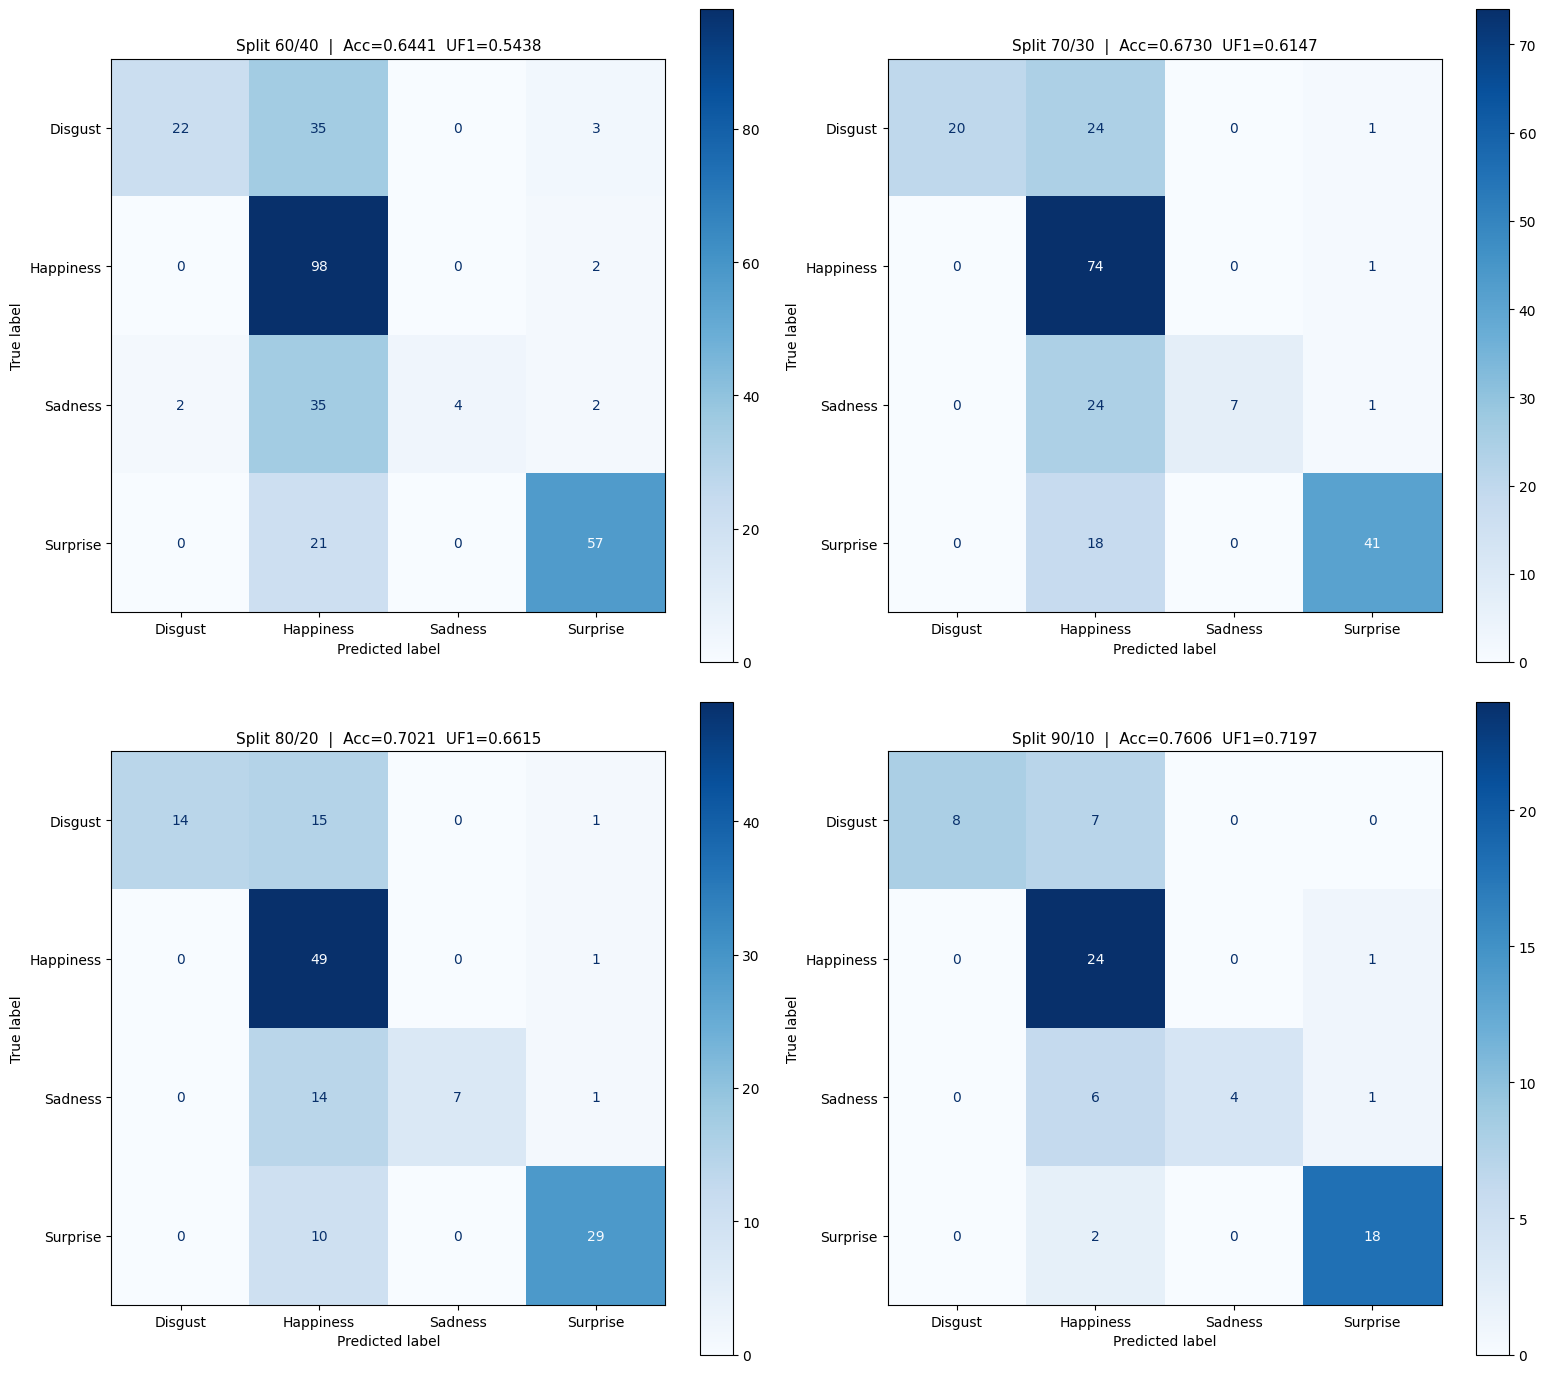

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
for ax, r in zip(axes.flatten(), results):
    cm = confusion_matrix(r["y_val"], r["y_val_pred"])
    ConfusionMatrixDisplay(cm, display_labels=le.classes_).plot(ax=ax, cmap="Blues", values_format="d")
    ax.set_title(f'Split {r["split"]}  |  Acc={r["val_acc"]:.4f}  UF1={r["val_f1"]:.4f}', fontsize=11)
plt.tight_layout()
plt.show()

## 6. Best Split

In [13]:
best = max(results, key=lambda r: r["val_f1"])
print(f"Best split: {best['split']} (Val UF1={best['val_f1']:.4f})\n")
print(classification_report(best["y_val"], best["y_val_pred"], target_names=le.classes_))

Best split: 90/10 (Val UF1=0.7197)

              precision    recall  f1-score   support

     Disgust       1.00      0.53      0.70        15
   Happiness       0.62      0.96      0.75        25
     Sadness       1.00      0.36      0.53        11
    Surprise       0.90      0.90      0.90        20

    accuracy                           0.76        71
   macro avg       0.88      0.69      0.72        71
weighted avg       0.84      0.76      0.75        71



## 7. External Test

In [14]:
y_ext_pred = predict(best["model"], X_ext)

ext_acc = accuracy_score(y_ext, y_ext_pred)
ext_f1 = f1_score(y_ext, y_ext_pred, average="macro")
ext_uar = recall_score(y_ext, y_ext_pred, average="macro")

print(f"External Test — Acc: {ext_acc:.4f}  UF1: {ext_f1:.4f}  UAR: {ext_uar:.4f}")
print(f"\n{classification_report(y_ext, y_ext_pred, target_names=le.classes_)}")

External Test — Acc: 0.1333  UF1: 0.1050  UAR: 0.2194

              precision    recall  f1-score   support

     Disgust       0.14      0.04      0.06       105
   Happiness       0.12      0.71      0.20        55
     Sadness       1.00      0.01      0.01       161
    Surprise       0.17      0.12      0.14       129

    accuracy                           0.13       450
   macro avg       0.36      0.22      0.11       450
weighted avg       0.45      0.13      0.08       450



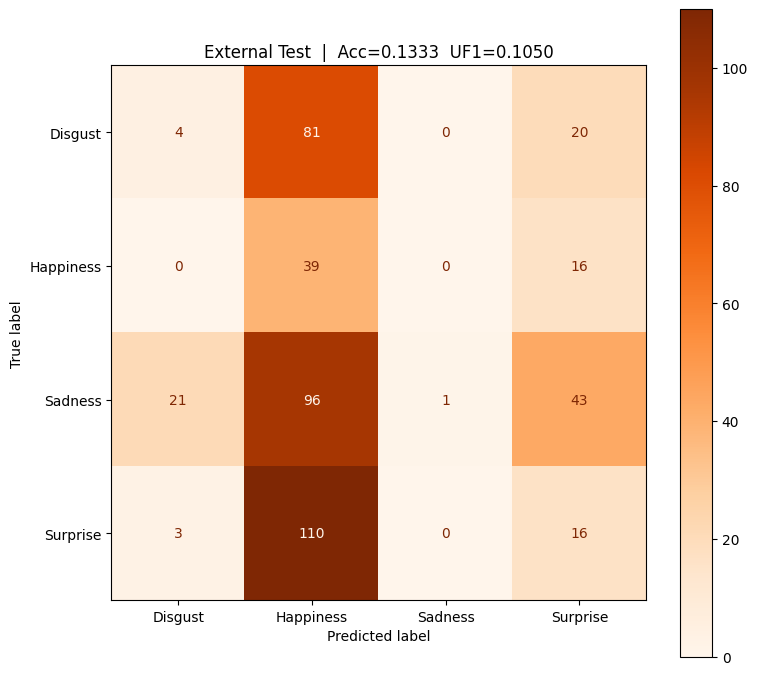

In [15]:
fig, ax = plt.subplots(figsize=(8, 7))
cm_ext = confusion_matrix(y_ext, y_ext_pred)
ConfusionMatrixDisplay(cm_ext, display_labels=le.classes_).plot(ax=ax, cmap="Oranges", values_format="d")
ax.set_title(f"External Test  |  Acc={ext_acc:.4f}  UF1={ext_f1:.4f}", fontsize=12)
plt.tight_layout()
plt.show()

## 8. Ringkasan

In [16]:
summary = pd.DataFrame([{
    "Split": r["split"],
    "Train Acc": f'{r["train_acc"]:.4f}',
    "Val Acc": f'{r["val_acc"]:.4f}',
    "Val UF1": f'{r["val_f1"]:.4f}',
    "Val UAR": f'{r["val_uar"]:.4f}',
} for r in results])

summary = pd.concat([summary, pd.DataFrame([{
    "Split": f"External ({best['split']})",
    "Train Acc": "-",
    "Val Acc": f"{ext_acc:.4f}",
    "Val UF1": f"{ext_f1:.4f}",
    "Val UAR": f"{ext_uar:.4f}",
}])], ignore_index=True)

print(summary.to_string(index=False))
summary

           Split Train Acc Val Acc Val UF1 Val UAR
           60/40    0.7643  0.6441  0.5438  0.5426
           70/30    0.7714  0.6730  0.6147  0.5862
           80/20    0.7536  0.7021  0.6615  0.6271
           90/10    0.7825  0.7606  0.7197  0.6892
External (90/10)         -  0.1333  0.1050  0.2194


,Split,Train Acc,Val Acc,Val UF1,Val UAR
0,60/40,0.7643,0.6441,0.5438,0.5426
1,70/30,0.7714,0.6730,0.6147,0.5862
2,80/20,0.7536,0.7021,0.6615,0.6271
3,90/10,0.7825,0.7606,0.7197,0.6892
4,External (90/10),-,0.1333,0.1050,0.2194
